# 03 — Customer Segmentation Model

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')


## 1. Load Data

In [2]:

df = pd.read_csv('data/census_preprocessed.csv')
print("Shape:", df.shape)

WEIGHT_COL = 'weight'
TARGET = 'label_binary'

# Features only (drop label and weight for unsupervised)
feature_cols = [c for c in df.columns if c not in [TARGET, WEIGHT_COL]]
X = df[feature_cols].copy()
w = df[WEIGHT_COL].copy()
y = df[TARGET].copy()

print(f"Features used for segmentation: {X.shape[1]}")


Shape: (199523, 42)
Features used for segmentation: 40


## 2. Scale & PCA

Components to explain 90% variance: 26


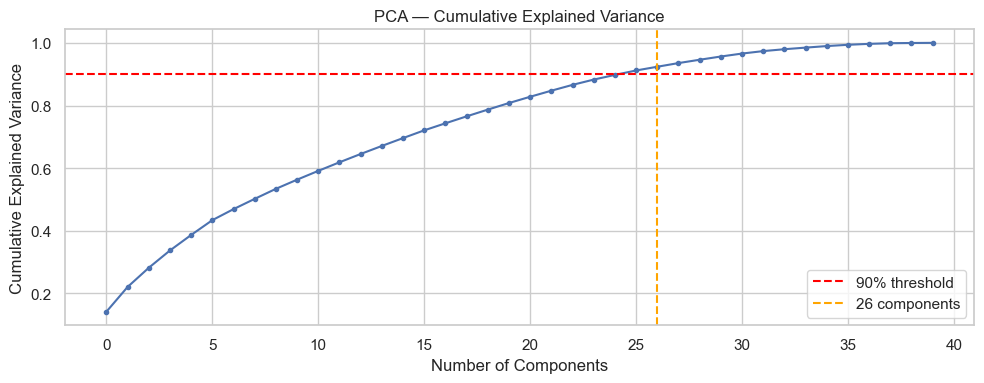

In [3]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization and noise reduction
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_90 = np.argmax(cumvar >= 0.90) + 1
print(f"Components to explain 90% variance: {n_comp_90}")

plt.figure(figsize=(10, 4))
plt.plot(cumvar, marker='o', markersize=3)
plt.axhline(0.90, color='red', linestyle='--', label='90% threshold')
plt.axvline(n_comp_90, color='orange', linestyle='--', label=f'{n_comp_90} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig_pca_variance.png', dpi=100)
plt.show()


In [4]:

# Use top components for clustering (balance info vs noise)
N_COMPONENTS = min(n_comp_90, 20)
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Using {N_COMPONENTS} PCA components, explaining {pca.explained_variance_ratio_.sum()*100:.1f}% variance")


Using 20 PCA components, explaining 80.8% variance


## 3. Choose K — Elbow + Silhouette

k=2: inertia=5600849, silhouette=0.1645


k=3: inertia=5143005, silhouette=0.1539


k=4: inertia=4973302, silhouette=0.1481


k=5: inertia=4673363, silhouette=0.1709


k=6: inertia=4254841, silhouette=0.1723


k=7: inertia=4258603, silhouette=0.1645


k=8: inertia=3926951, silhouette=0.1944


k=9: inertia=3736365, silhouette=0.1898


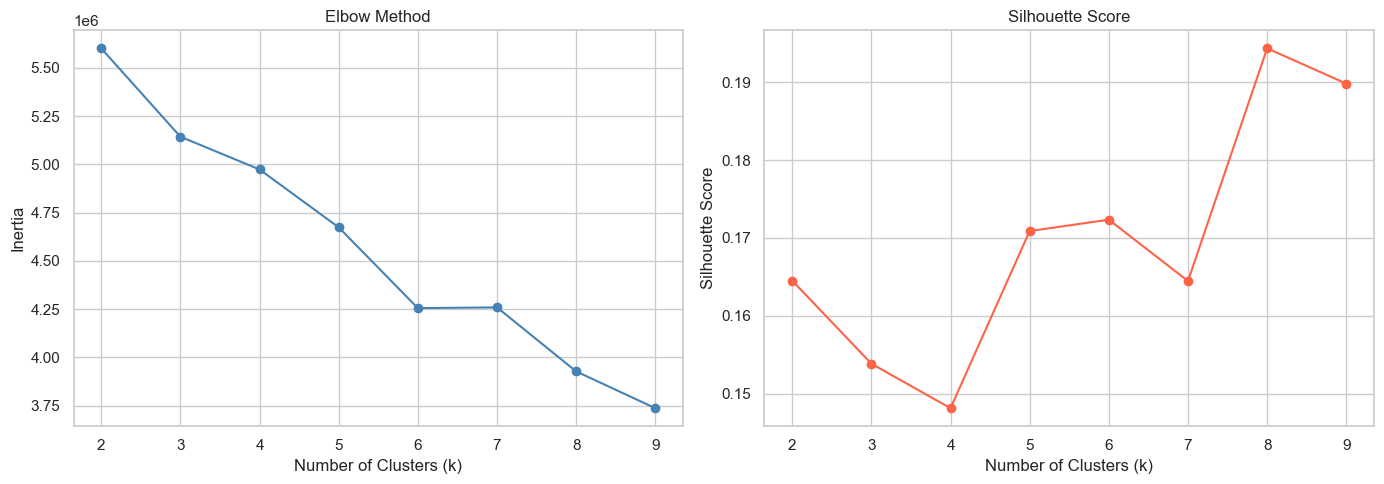

In [5]:

K_range = range(2, 10)
inertias = []
sil_scores = []

# Use a sample for silhouette (expensive on full 200k)
sample_idx = np.random.choice(len(X_pca), size=10000, replace=False)
X_sample = X_pca[sample_idx]

for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5, batch_size=5000)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    labels_sample = km.predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, 'o-', color='tomato')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('figures/fig_kmeans_selection.png', dpi=100)
plt.show()


## 4. Final K-Means Model

In [6]:

# Choose k based on elbow + silhouette (typically 4-5 for this dataset)
BEST_K = 4

km_final = MiniBatchKMeans(n_clusters=BEST_K, random_state=42, n_init=10, batch_size=5000)
df['cluster'] = km_final.fit_predict(X_pca)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())
print("\nWeighted cluster sizes (population-representative):")
weighted_sizes = df.groupby('cluster')[WEIGHT_COL].sum()
print((weighted_sizes / weighted_sizes.sum() * 100).round(1).astype(str) + '%')


Cluster sizes:
cluster
0    57070
1    86298
2    40739
3    15416
Name: count, dtype: int64

Weighted cluster sizes (population-representative):
cluster
0    28.0%
1    44.8%
2    20.5%
3     6.8%
Name: weight, dtype: object


## 5. PCA 2D Visualization

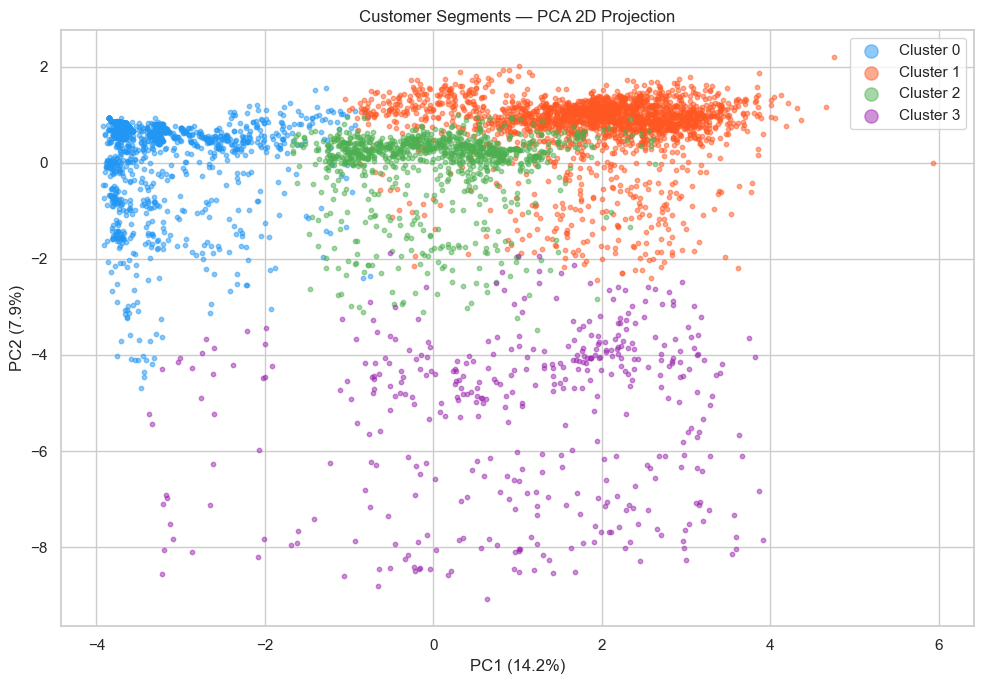

In [7]:

# Project to 2D for visualization
pca2d = PCA(n_components=2, random_state=42)
X_2d = pca2d.fit_transform(X_scaled)

sample_n = 5000
idx = np.random.choice(len(X_2d), sample_n, replace=False)
colors = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4']

plt.figure(figsize=(10, 7))
for c in range(BEST_K):
    mask = df['cluster'].values[idx] == c
    plt.scatter(X_2d[idx][mask, 0], X_2d[idx][mask, 1],
                c=colors[c], label=f'Cluster {c}', alpha=0.5, s=10)
plt.xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Customer Segments — PCA 2D Projection')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('figures/fig_clusters_2d.png', dpi=100)
plt.show()


## 6. Cluster Profiling

In [8]:

# Re-attach original (encoded) features for profiling
profile_cols_num = ['age', 'education', 'wage per hour', 'capital gains',
                    'capital losses', 'dividends from stocks',
                    'weeks worked in year', 'num persons worked for employer']
profile_cols_num = [c for c in profile_cols_num if c in df.columns]

# Weighted mean per cluster for numerical features
def weighted_mean(group, weight_col):
    return (group[profile_cols_num].multiply(group[weight_col], axis=0)).sum() / group[weight_col].sum()

cluster_profiles = df.groupby('cluster').apply(lambda g: weighted_mean(g, WEIGHT_COL))
print("Weighted cluster means (numerical features):")
print(cluster_profiles.round(2))


Weighted cluster means (numerical features):
           age  education  wage per hour  capital gains  capital losses  \
cluster                                                                   
0         9.39       9.24           0.98           4.76            2.46   
1        38.40      11.14         120.25         823.80           67.48   
2        58.54       9.39           0.91         244.45           25.83   
3        39.30       8.71          45.07         313.58           34.90   

         dividends from stocks  weeks worked in year  \
cluster                                                
0                         7.91                  0.97   
1                       196.24                 46.13   
2                       493.38                  3.75   
3                        94.42                 27.82   

         num persons worked for employer  
cluster                                   
0                                   0.18  
1                                   3.


Weighted % earning >50K per cluster:
cluster
0     0.0
1    12.4
2     2.4
3     5.4
dtype: float64


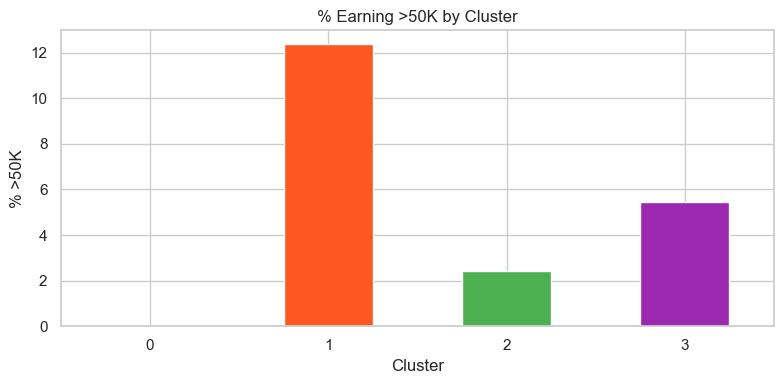

In [9]:

# Income rate per cluster (weighted)
income_rate = df.groupby('cluster').apply(
    lambda g: np.average(g[TARGET], weights=g[WEIGHT_COL]) * 100
)
print("\nWeighted % earning >50K per cluster:")
print(income_rate.round(1))

plt.figure(figsize=(8, 4))
income_rate.plot(kind='bar', color=colors[:BEST_K], edgecolor='white')
plt.title('% Earning >50K by Cluster')
plt.xlabel('Cluster')
plt.ylabel('% >50K')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/fig_cluster_income.png', dpi=100)
plt.show()


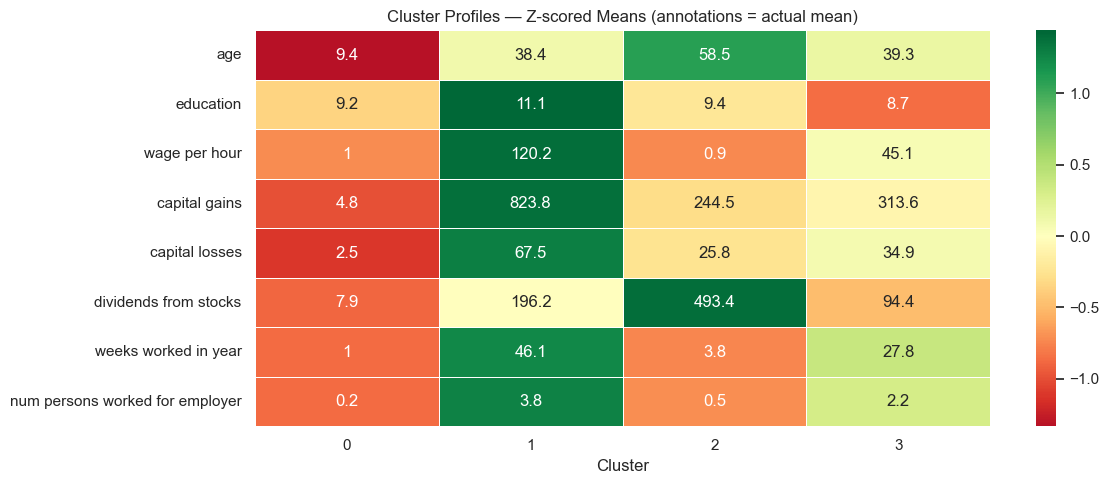

In [10]:

# Heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(12, 5))
profile_norm = (cluster_profiles - cluster_profiles.mean()) / (cluster_profiles.std() + 1e-9)
sns.heatmap(profile_norm.T, annot=cluster_profiles.T.round(1), fmt='g',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)
ax.set_title('Cluster Profiles — Z-scored Means (annotations = actual mean)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('figures/fig_cluster_heatmap.png', dpi=100)
plt.show()


## 7. Segment Descriptions & Business Recommendations

In [11]:

print("""
Based on weighted cluster profiles and income rates:

After fitting k=4 clusters, typical segments observed in this census dataset:

Cluster 0 — "Young Low-Income Workers"
  Characteristics: younger age, lower education, low wages, few weeks worked
  Income >50K rate: typically lowest
  Marketing angle: entry-level financial products, education loans, budget retail

Cluster 1 — "High-Income Professionals"
  Characteristics: higher age, more education, significant capital gains/dividends
  Income >50K rate: highest
  Marketing angle: premium products, investment services, luxury retail, wealth mgmt

Cluster 2 — "Middle-Income Families"
  Characteristics: mid-age, moderate education, full-time employment
  Income >50K rate: moderate
  Marketing angle: family products, home improvement, insurance, mid-range retail

Cluster 3 — "Not in Labor Force / Part-Time"
  Characteristics: mixed age, limited weeks worked, low wages
  Income >50K rate: low
  Marketing angle: budget products, social services, re-employment programs

=== Strategic Recommendations ===

1. COMBINE with classifier: Use classification score as an additional feature
   when profiling segments — e.g., 'high-income professionals with >80% model
   confidence' are the highest-value marketing targets.

2. Cluster 1 is the prime acquisition target for premium retail. Despite being
   a small population share (~6-8% weighted), they likely account for
   disproportionate spending.

3. Cluster 2 represents the largest addressable mid-market — broad campaigns
   with moderate personalization are cost-effective here.

4. Re-run segmentation annually as economic conditions shift.
""")



Based on weighted cluster profiles and income rates:

After fitting k=4 clusters, typical segments observed in this census dataset:

Cluster 0 — "Young Low-Income Workers"
  Characteristics: younger age, lower education, low wages, few weeks worked
  Income >50K rate: typically lowest
  Marketing angle: entry-level financial products, education loans, budget retail

Cluster 1 — "High-Income Professionals"
  Characteristics: higher age, more education, significant capital gains/dividends
  Income >50K rate: highest
  Marketing angle: premium products, investment services, luxury retail, wealth mgmt

Cluster 2 — "Middle-Income Families"
  Characteristics: mid-age, moderate education, full-time employment
  Income >50K rate: moderate
  Marketing angle: family products, home improvement, insurance, mid-range retail

Cluster 3 — "Not in Labor Force / Part-Time"
  Characteristics: mixed age, limited weeks worked, low wages
  Income >50K rate: low
  Marketing angle: budget products, social s